In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [118]:
s = 50
img = Image.open('./image.png')
img = img.resize((img.size[0]//s, img.size[1]//s))
vector = 2*(np.asarray(img, np.float32)/255 - 0.5)
img.close()

In [119]:
target = np.array([vector])

In [120]:
def show_normed(vector):
    plt.imshow((vector + 1)/2)
    plt.show()

def image_dot(a, b, keepdims = False):
    return np.sum(a*b, (1, 2, 3), keepdims = keepdims)

In [121]:
from functools import reduce


reduce(lambda x, y:x*y, vector.shape)

1701

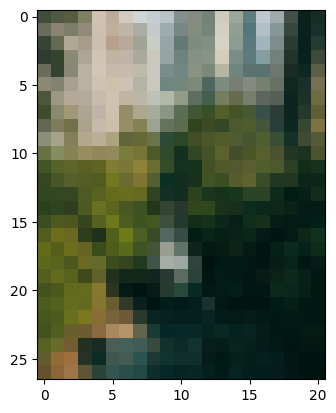

In [122]:
show_normed(vector)

In [123]:
def normalize(basis):
    r = image_dot(basis, basis, True)**0.5
    return basis / r

In [136]:
N = 50
basis = np.random.randn(N, *vector.shape)
basis = normalize(basis)

In [137]:
def optim(basis, N = 10):
    B = basis.reshape(basis.shape[0], basis.shape[1]*basis.shape[2]*basis.shape[3])
    I = np.eye(B.shape[-1])
    for _ in range(N):
        B = 0.5*B @ (3*I - B.T @ B)
        # B /= (B**2).sum(-1, keepdims = True)**0.5
    return B.reshape(*basis.shape)

def cosins():
    q =basis.reshape(basis.shape[0], basis.shape[1]*basis.shape[2]*basis.shape[3])
    plt.imshow(q @ q.T)

def show_angles(basis):
    q = basis.reshape(basis.shape[0], basis.shape[1]*basis.shape[2]*basis.shape[3])
    plt.imshow(q @ q.T)
    plt.colorbar()
    plt.show()

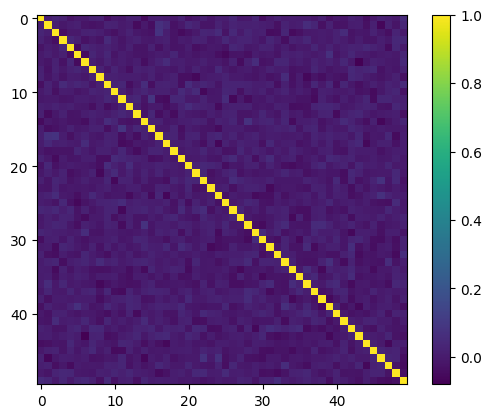

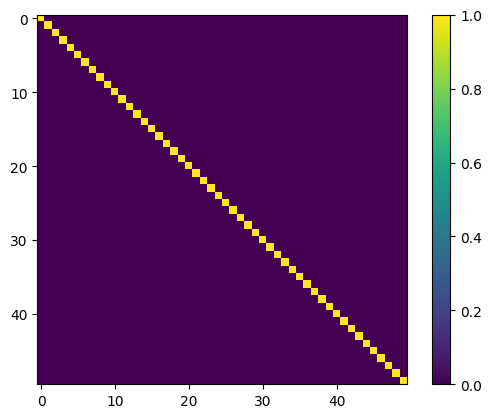

In [138]:
show_angles(basis)
basis = optim(basis)
show_angles(basis)

In [139]:
c = image_dot(target, basis, True)

In [140]:
b = (c*basis).sum(0)

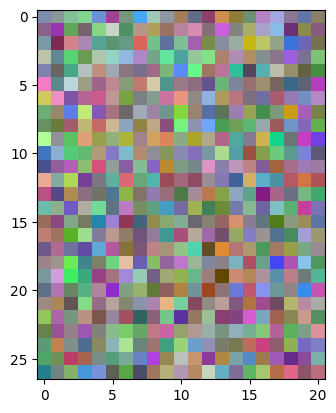

In [141]:
show_normed(2*((b - b.min())/(b.max() - b.min()) - 0.5))